<a href="https://colab.research.google.com/github/abhishekrs2003/ICT_DSA_2026/blob/main/Unsupervised_learning_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Unsupervised Learning Case Study

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# libraries for scaling and encoding
from sklearn.preprocessing import StandardScaler,MinMaxScaler, LabelEncoder, RobustScaler

#clustering
from sklearn.cluster import KMeans

In [78]:
file_path = "/content/drive/MyDrive/DSA Works/Datasets/adult_dataset.csv"

In [79]:
adult_data_df = pd.read_csv(file_path)

In [80]:
adult_data_df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


### Data preprocessing

In [81]:
# getting information about datatypes of the data
adult_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [82]:
# Getting statistical summary of the data
adult_data_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [83]:
#checking for null values
adult_data_df.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [84]:
# checking percentage of missing values
missing_percent = adult_data_df.isna().sum()/len(adult_data_df)*100 # checking the percentage of missing values
sorted = missing_percent.sort_values(ascending=True)
sorted

,0
education,0.000000
fnlwgt,0.000000
marital-status,0.000000
education-num,0.000000
relationship,0.000000
capital-gain,0.000000
sex,0.000000
race,0.000000
income,0.000000
capital-loss,0.000000


In [85]:
num_cols = adult_data_df.select_dtypes(include=['number']).columns # to get the column name with numerical data
cat_cols = adult_data_df.select_dtypes(include=['object']).columns # to get the column name with catogoecal data

In [86]:
num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [87]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

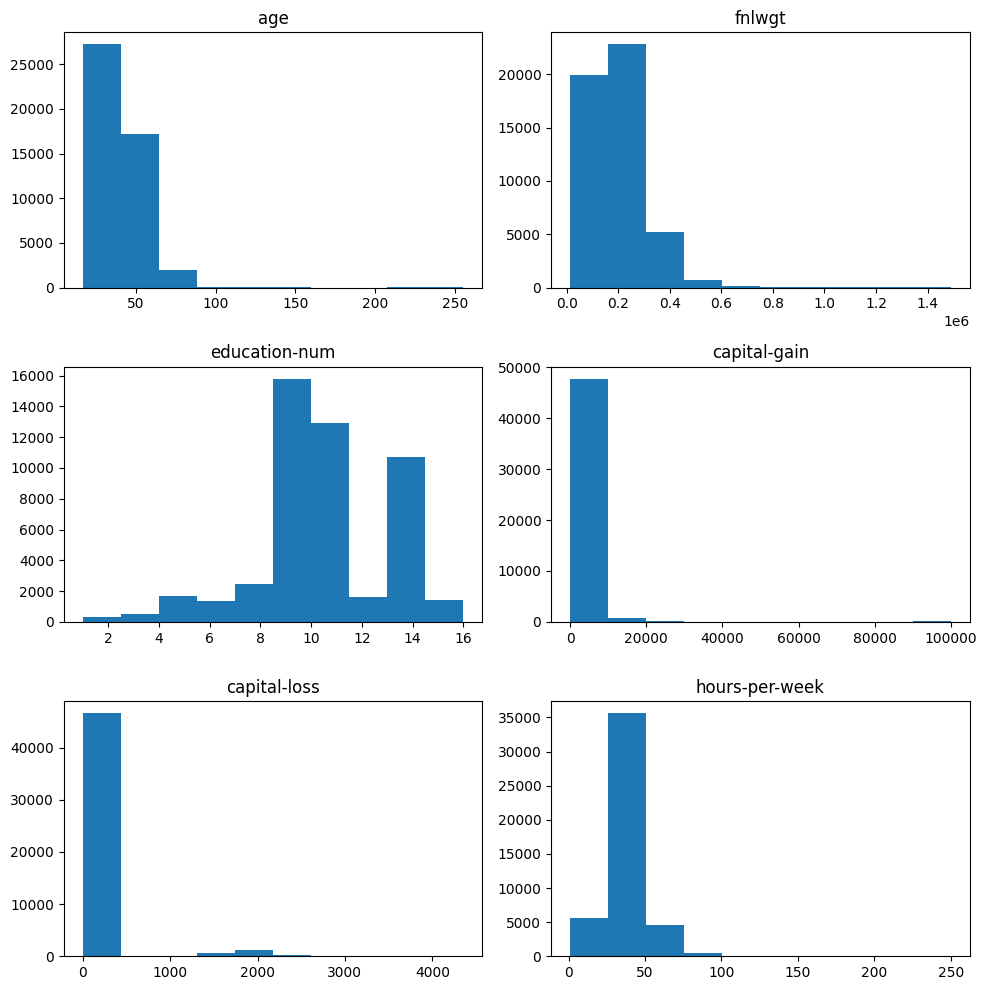

In [88]:
# using iterative method to plot all histograms in a single
plt.figure(figsize=(10,10))
for i, col in enumerate(num_cols,1):
  plt.subplot(3,2,i)
  plt.hist(adult_data_df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [89]:
# the graph is skewed for all numerical colums so we replace it with the median
adult_data_df['age'].fillna(adult_data_df['age'].median(), inplace=True)
adult_data_df['hours-per-week'].fillna(adult_data_df['hours-per-week'].median(), inplace=True)

/tmp/ipykernel_5730/2957915838.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data_df['age'].fillna(adult_data_df['age'].median(), inplace=True)
/tmp/ipykernel_5730/2957915838.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [90]:
adult_data_df['occupation'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', nan, 'Protective-serv', '?', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [91]:
# three columns has ? as data it should be replaced with nan and later with mode
question_cols = (adult_data_df == '?').sum()
question_cols[question_cols > 0]

,0
workclass,1763
occupation,1758
native-country,555


In [92]:
# replacing columns which has '?' with nan
adult_data_df.replace('?', np.nan, inplace=True)

In [93]:
# checking percentage of missing values
missing_percent = adult_data_df.isna().sum()/len(adult_data_df)*100 # checking the percentage of missing values
sorted = missing_percent.sort_values(ascending=True)
sorted

,0
age,0.000000
fnlwgt,0.000000
education,0.000000
education-num,0.000000
relationship,0.000000
marital-status,0.000000
sex,0.000000
race,0.000000
hours-per-week,0.000000
income,0.000000


In [94]:
# replacing catogorical data with mode
adult_data_df['native-country'].fillna(adult_data_df['native-country'].mode()[0],inplace=True)
adult_data_df['occupation'].fillna(adult_data_df['occupation'].mode()[0],inplace=True)
adult_data_df['workclass'].fillna(adult_data_df['workclass'].mode()[0],inplace=True)

/tmp/ipykernel_5730/1526503038.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data_df['native-country'].fillna(adult_data_df['native-country'].mode()[0],inplace=True)
/tmp/ipykernel_5730/1526503038.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

In [95]:
adult_data_df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


###Handiling duplicates

In [96]:
adult_data_df.duplicated().sum()

np.int64(22)

In [97]:
# removing duplicates
adult_data_df.drop_duplicates(inplace=True)
adult_data_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [98]:
adult_data_df.duplicated().sum()

np.int64(0)

### Handling Outliers

In [99]:
adult_data_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48820.000000,4.882000e+04,48820.000000,48820.000000,48820.000000,48820.000000
mean,38.597890,1.896605e+05,10.078554,1079.553892,87.541745,40.428165
std,13.603254,1.056057e+05,2.570387,7453.662758,403.091066,12.326679
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175535e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781350e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376210e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


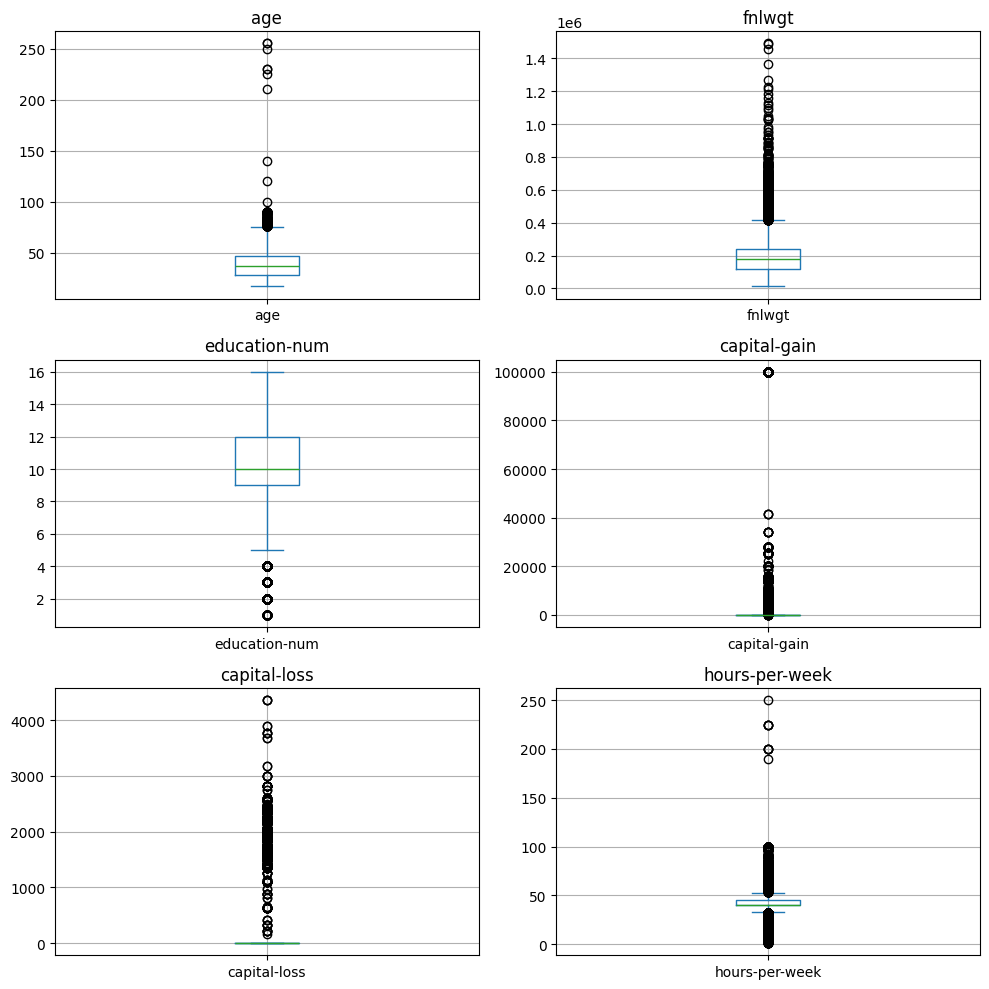

In [100]:
# ploting using box plot to identify outliers
plt.figure(figsize=(10,10))
for i, col in enumerate(num_cols,1):
  plt.subplot(3,2,i)
  adult_data_df[col].plot(kind = 'box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [101]:
Q1 = adult_data_df[num_cols].quantile(0.25)
Q3 = adult_data_df[num_cols].quantile(0.75)
IQR = Q3-Q1


upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((adult_data_df[num_cols] > upper_limit) | (adult_data_df[num_cols] < lower_limit)).any(axis=1)

outliers_df = adult_data_df[outliers]

outlier_percentage = len(outliers_df) * 100/ len(adult_data_df)

print("percentage fo outliers in the dataframe :", outlier_percentage)

percentage fo outliers in the dataframe : 40.448586644817695


In [102]:
# use log transformation for capital gain and capital loss as the data si highly skewed
adult_data_df['capital-gain'] = np.log1p(adult_data_df['capital-gain'])
adult_data_df['capital-loss'] = np.log1p(adult_data_df['capital-loss'])

In [103]:
num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [104]:
# avoiding cliping capital gain and capital loss as the data is highly skewed rather than using logp to compress th data
clip_cols = ['age','fnlwgt','education-num']

In [105]:
# here the outlier percentage is high so we clip the outliers
adult_data_df[clip_cols] = adult_data_df[clip_cols].clip(lower_limit, upper_limit, axis=1)

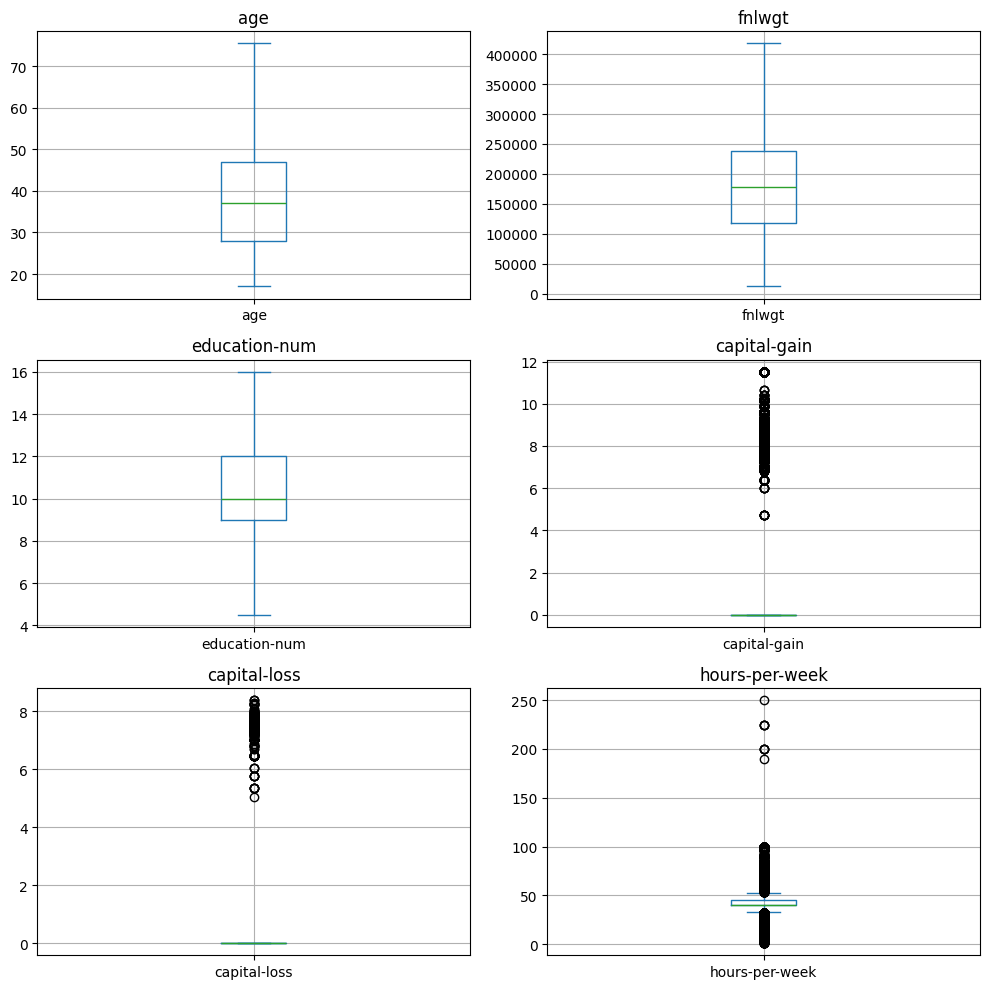

In [106]:
# ploting using box plot to identify outliers after clipping
plt.figure(figsize=(10,10))
for i, col in enumerate(num_cols,1):
  plt.subplot(3,2,i)
  adult_data_df[col].plot(kind = 'box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [107]:
adult_data_df.count()

,0
age,48820
workclass,48820
fnlwgt,48820
education,48820
education-num,48820
marital-status,48820
occupation,48820
relationship,48820
race,48820
sex,48820


### Identifying Corelation

In [108]:
# corelation
corr_matrix = adult_data_df[num_cols].corr(method='pearson')
corr_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076926,0.041663,0.121232,0.051813,0.076371
fnlwgt,-0.076926,1.000000,-0.034857,-0.007158,-0.001766,-0.011605
education-num,0.041663,-0.034857,1.000000,0.132561,0.080450,0.139902
capital-gain,0.121232,-0.007158,0.132561,1.000000,-0.065950,0.080995
capital-loss,0.051813,-0.001766,0.080450,-0.065950,1.000000,0.048164
hours-per-week,0.076371,-0.011605,0.139902,0.080995,0.048164,1.000000


In [109]:
adult_data_df['capital-gain'].describe()

,capital-gain
count,48820.000000
mean,0.728873
std,2.445982
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,11.512925


In [110]:
adult_data_df['capital-loss'].describe()

,capital-loss
count,48820.000000
mean,0.351131
std,1.586572
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,8.379539


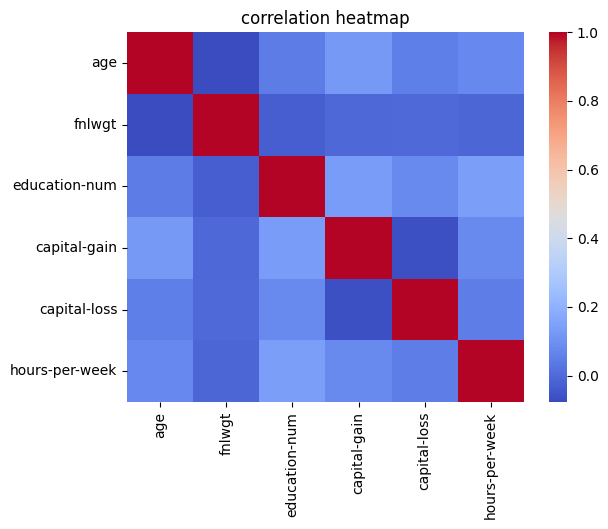

In [111]:
# ploting a heat map to visualize correlation
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [112]:
# removing 'education' as 'education num' and 'education' represent same information
adult_data_df.drop('education', axis=1, inplace=True)

In [113]:
# droping income as it is the clusters we want to identify
adult_data_df.drop('income', axis=1, inplace=True)

In [114]:
cat_cols= cat_cols.drop('education')

In [115]:
cat_cols = cat_cols.drop('income')

In [116]:
adult_data_df.drop('fnlwgt',axis=1,inplace=True)

In [117]:
num_cols = num_cols.drop('fnlwgt')

In [118]:
adult_data_df.head(2)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,7.684784,0.0,40.0,United-States
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,13.0,United-States


###Data Transformation

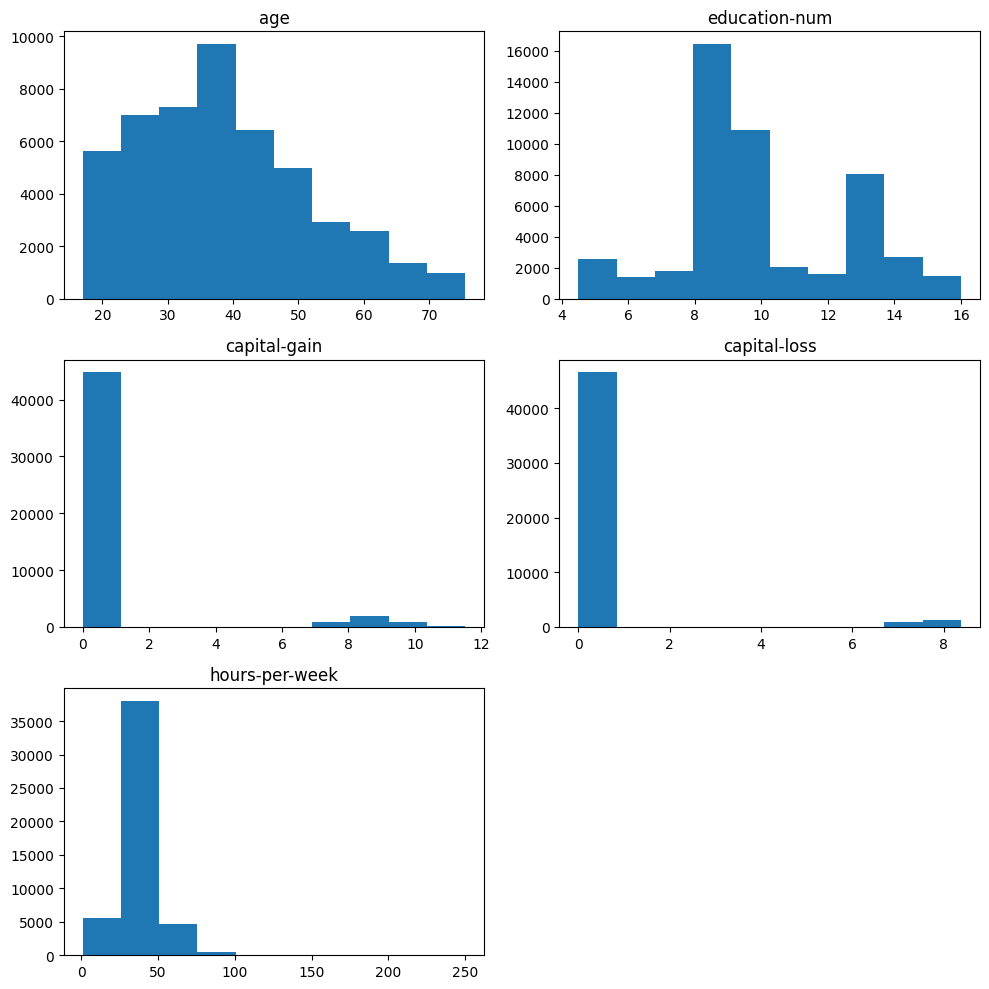

In [119]:
plt.figure(figsize=(10,10))
for i, col in enumerate(num_cols,1):
  plt.subplot(3,2,i)
  plt.hist(adult_data_df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [120]:
# every data is skwed so we use min - max sclaer

In [121]:
adult_data_df.describe() # before scaling

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48820.000000,48820.000000,48820.000000,48820.000000,48820.000000
mean,38.534381,10.122409,0.728873,0.351131,40.428165
std,13.270644,2.456667,2.445982,1.586572,12.326679
min,17.000000,4.500000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,12.000000,0.000000,0.000000,45.000000
max,75.500000,16.000000,11.512925,8.379539,250.000000


In [122]:
standart_scaler = StandardScaler()
adult_data_df[['age','education-num','capital-gain','capital-loss','hours-per-week']] = standart_scaler.fit_transform(adult_data_df[['age','education-num','capital-gain','capital-loss','hours-per-week']])

In [123]:
adult_data_df.describe() # after scaling

,age,education-num,capital-gain,capital-loss,hours-per-week
count,4.882000e+04,4.882000e+04,4.882000e+04,4.882000e+04,4.882000e+04
mean,-2.095825e-16,-1.761075e-16,1.368108e-17,4.817486e-17,1.171624e-16
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.622725e+00,-2.288657e+00,-2.979908e-01,-2.213165e-01,-3.198637e+00
25%,-7.938190e-01,-4.568875e-01,-2.979908e-01,-2.213165e-01,-3.473515e-02
50%,-1.156234e-01,-4.982772e-02,-2.979908e-01,-2.213165e-01,-3.473515e-02
75%,6.379272e-01,7.642919e-01,-2.979908e-01,-2.213165e-01,3.708933e-01
max,2.785547e+00,2.392531e+00,4.408930e+00,5.060274e+00,1.700166e+01


In [124]:
# corelation after scaling
corr_matrix = adult_data_df[num_cols].corr(method='pearson')
corr_matrix

,age,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,0.041663,0.121232,0.051813,0.076371
education-num,0.041663,1.000000,0.132561,0.080450,0.139902
capital-gain,0.121232,0.132561,1.000000,-0.065950,0.080995
capital-loss,0.051813,0.080450,-0.065950,1.000000,0.048164
hours-per-week,0.076371,0.139902,0.080995,0.048164,1.000000


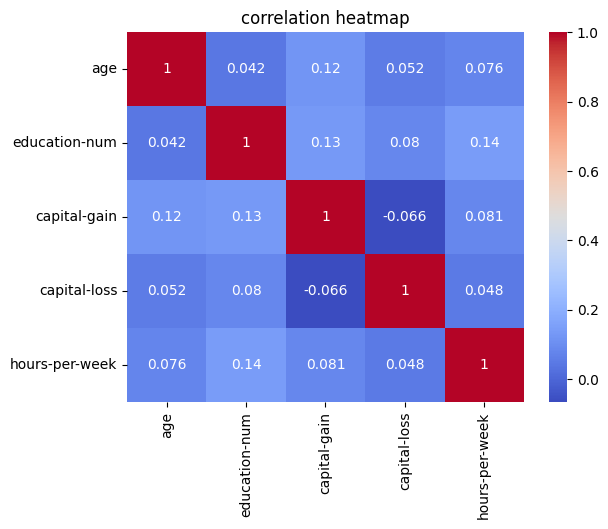

In [125]:
# ploting a heat map to visualize correlation after scaling
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

###Encoding

In [126]:
cat_cols

Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country'],
      dtype='object')

In [127]:
adult_data_df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [128]:
adult_data_df['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse',
       'Widowed'], dtype=object)

In [129]:
adult_data_df['occupation'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [130]:
adult_data_df['relationship'].unique()

array(['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'], dtype=object)

In [131]:
adult_data_df['race'].unique()

array(['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo',
       'Other'], dtype=object)

In [132]:
adult_data_df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [133]:
adult_data_df['native-country'].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', 'Mexico', 'South',
       'Puerto-Rico', 'Honduras', 'England', 'Germany', 'Iran',
       'Philippines', 'Italy', 'Columbia', 'Cambodia', 'Thailand',
       'Canada', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'Poland', 'France',
       'Guatemala', 'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

In [134]:
adult_data_df['native-country'].value_counts()

,count
native-country,
United-States,44865
Mexico,905
Philippines,282
Germany,194
Puerto-Rico,175
Canada,170
El-Salvador,147
India,143
Cuba,132


In [135]:
# making values in native country as united states and other countires as peoples from other countries are too low in  number
# adult_data_df['native-country'] = adult_data_df['native-country'].apply(
#     lambda x: 'United-States' if x == 'United-States' else 'Other'
# )

In [136]:
# Label encoding - 'sex' as it is binanry data
# rest  of the coulms one hot encoding

label_encoder = LabelEncoder()

adult_data_df['sex'] = label_encoder.fit_transform(adult_data_df['sex'])

In [137]:
# doing one hot encoding on mentioned columns
adult_data_df = pd.get_dummies(adult_data_df, columns=['workclass','marital-status','occupation','relationship','race','native-country'], dtype=int)

In [138]:
adult_data_df.head(5)

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.035087,1.171352,1,2.843841,-0.221316,-0.034735,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0.863992,1.171352,1,-0.297991,-0.221316,-2.225129,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,-0.040268,-0.456888,1,-0.297991,-0.221316,-0.034735,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,1.090058,-1.271007,1,-0.297991,-0.221316,-0.034735,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,-0.793819,1.171352,0,-0.297991,-0.221316,-0.034735,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


###Clustering

In [139]:
X = adult_data_df

In [140]:
# list to store WcSS value for each value of K
WCSS = []

# find WCSS value for each K
for i in range(1,11):
  k_means_model = KMeans(n_clusters = i, n_init=5)

  #Model building
  k_means_model.fit(X)
  WCSS_value = k_means_model.inertia_ # value of WCSS for k = i

  WCSS.append(WCSS_value)

In [141]:
# checking WCSS values
WCSS

[405736.5558787389,
 355129.0462921186,
 310245.7798429807,
 281664.8951292512,
 244603.46021603138,
 229189.62614467603,
 219201.57966749492,
 211422.4980811976,
 205453.9296611699,
 196138.03359519865]

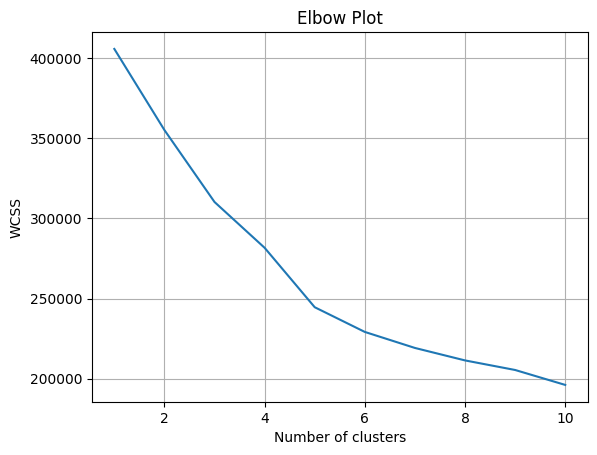

In [142]:
# elbow plot (k vs WCSS)

plt.plot(range(1,11), WCSS)
plt.title("Elbow Plot")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.grid()
plt.show()

In [143]:
# Optimum number of clusters is 4 inference from the elbow plot)

# now create a k means model with no of clusters = 4

# initialising model
k_means = KMeans(n_clusters = 4)

# model building
k_means.fit(X)

# model prediction
cluster_label = k_means.predict(X)
cluster_label


array([0, 1, 3, ..., 1, 0, 1], dtype=int32)

In [144]:
# updating the datafram with the cluster information
adult_data_df['Cluster'] = cluster_label

Text(0, 0.5, '')

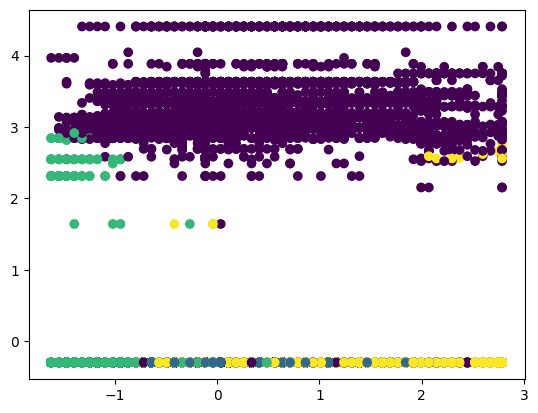

In [145]:
# plot showing Annual Income  Vs Spending Score

plt.scatter(adult_data_df['age'],
            adult_data_df['capital-gain'], c=adult_data_df['Cluster'])

plt.title("")
plt.xlabel("")
plt.ylabel("")

## 2. Exploratory Analysis – Dimensionality Reduction

### PCA – Principal Component Analysis
Reduce high-dimensional encoded data to 2 components for visual exploration of structure.

In [146]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Drop income column before clustering (not used in training)
income_col = adult_data_df['income'] if 'income' in adult_data_df.columns else None
X = adult_data_df.drop(columns=['income', 'education'], errors='ignore')

print('Feature matrix shape:', X.shape)

Feature matrix shape: (48820, 88)


In [147]:
# Apply PCA – reduce to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f'Explained variance by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'Explained variance by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total explained variance:  {pca.explained_variance_ratio_.sum()*100:.2f}%')

Explained variance by PC1: 22.07%
Explained variance by PC2: 14.36%
Total explained variance:  36.43%


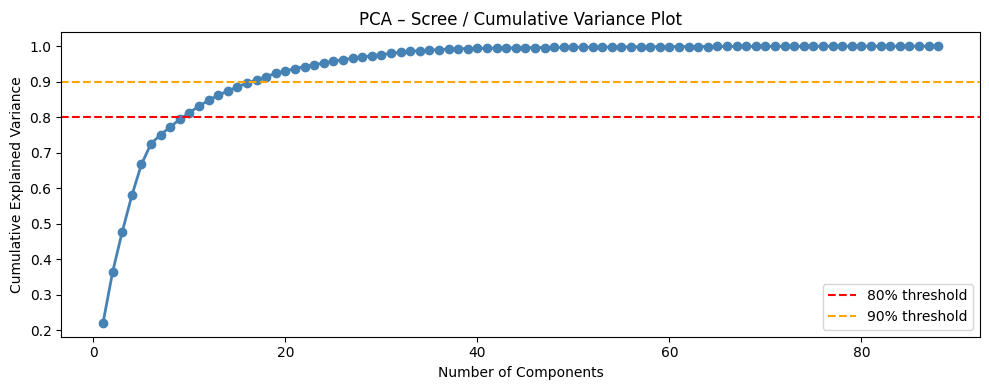

Components needed for 80% variance: 10
Components needed for 90% variance: 17


In [148]:
# Scree plot – how many components explain 80%+ variance?
pca_full = PCA(random_state=42)
pca_full.fit(X)
cumulative_var = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', linewidth=2, color='steelblue')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA – Scree / Cumulative Variance Plot')
plt.legend()
plt.tight_layout()
plt.show()

n_80 = (cumulative_var >= 0.80).argmax() + 1
n_90 = (cumulative_var >= 0.90).argmax() + 1
print(f'Components needed for 80% variance: {n_80}')
print(f'Components needed for 90% variance: {n_90}')

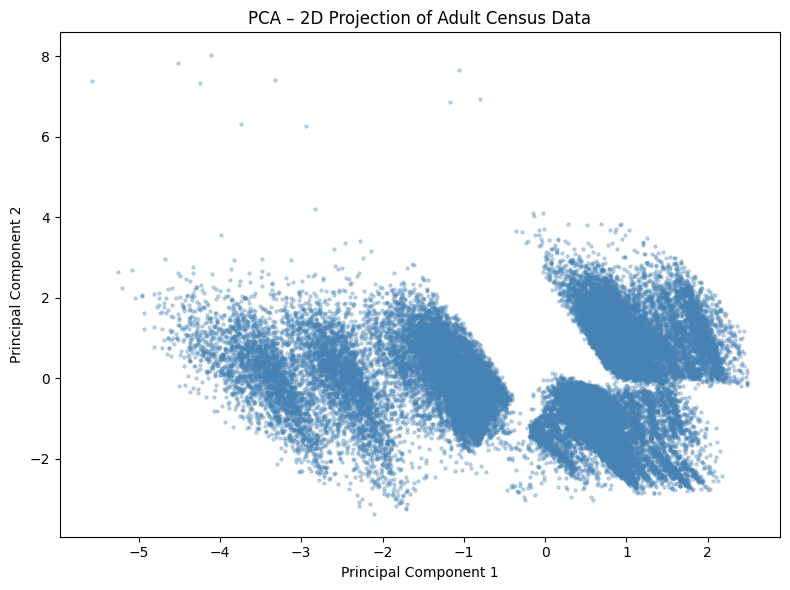

In [149]:
# PCA 2D scatter – unlabelled (no cluster labels yet)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=5, color='steelblue')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA – 2D Projection of Adult Census Data')
plt.tight_layout()
plt.show()

### t-SNE – Non-linear Dimensionality Reduction
t-SNE captures local neighbourhood structure that PCA may miss. We use a 10% sample for speed.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


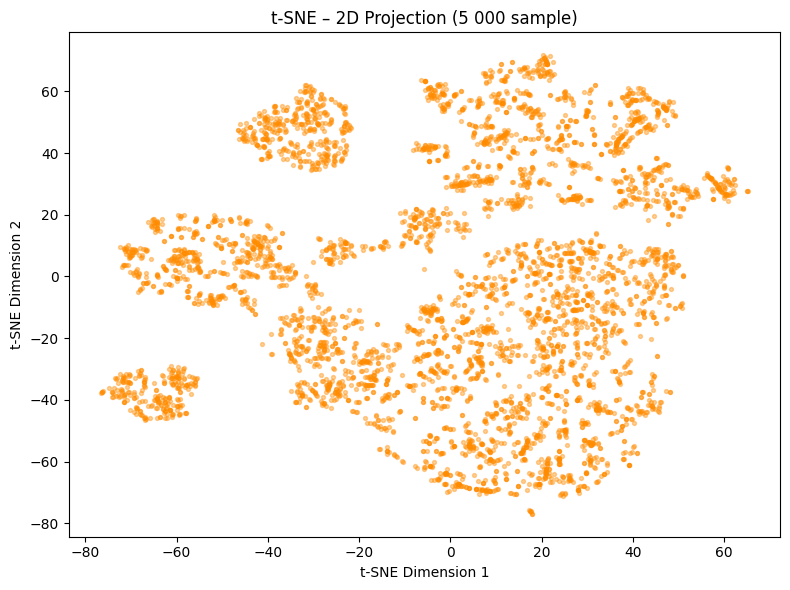

In [150]:
# t-SNE on a sample (full dataset is expensive)
import numpy as np
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=5000, replace=False)
X_sample = X.iloc[sample_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.4, s=8, color='darkorange')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE – 2D Projection (5 000 sample)')
plt.tight_layout()
plt.show()

## 3. Clustering

### 3a. KMeans – Choosing k with Elbow Method & Silhouette Score

In [151]:
# Use PCA-reduced data (faster) for elbow / silhouette sweep
# Reduce to 20 components (captures ~80% variance) for clustering
pca_20 = PCA(n_components=20, random_state=42)
X_pca20 = pca_20.fit_transform(X)
print('PCA-20 shape:', X_pca20.shape)

PCA-20 shape: (48820, 20)


In [152]:
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca20)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca20, labels, sample_size=5000, random_state=42))
    print(f'k={k}  inertia={km.inertia_:.0f}  silhouette={sil_scores[-1]:.4f}')

k=2  inertia=345219  silhouette=0.2322
k=3  inertia=297472  silhouette=0.2439
k=4  inertia=251979  silhouette=0.2175
k=5  inertia=212775  silhouette=0.2400
k=6  inertia=199170  silhouette=0.2233
k=7  inertia=189954  silhouette=0.2028
k=8  inertia=182572  silhouette=0.1978
k=9  inertia=175563  silhouette=0.1985
k=10  inertia=169010  silhouette=0.1960


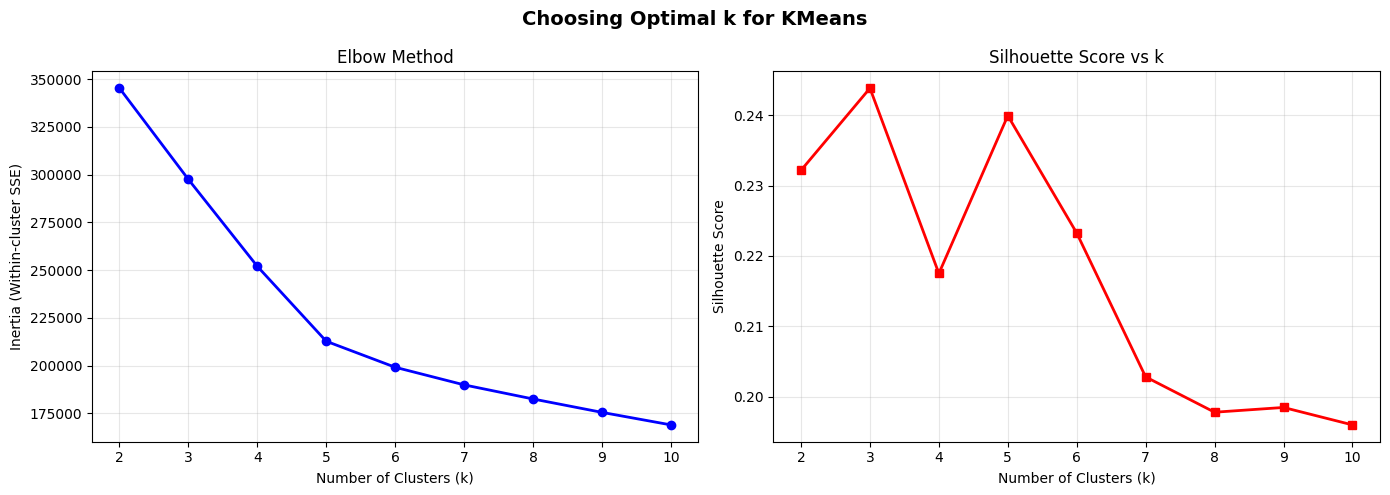


Best k by silhouette score: 3  (score=0.2439)


In [153]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(list(k_range), sil_scores, 'rs-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Choosing Optimal k for KMeans', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'\nBest k by silhouette score: {best_k}  (score={max(sil_scores):.4f})')

### 3b. KMeans – Final Model

In [154]:
# Train final KMeans with best k
BEST_K = best_k

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca20)

# Attach labels back to original data for profiling
adult_data_df['kmeans_cluster'] = kmeans_labels

final_sil = silhouette_score(X_pca20, kmeans_labels, sample_size=5000, random_state=42)
print(f'Final KMeans – k={BEST_K}, silhouette score={final_sil:.4f}')
print('\nCluster counts:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

Final KMeans – k=3, silhouette score=0.2439

Cluster counts:
0    32438
1     2281
2    14101
Name: count, dtype: int64


/tmp/ipykernel_5730/598572577.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10', BEST_K)


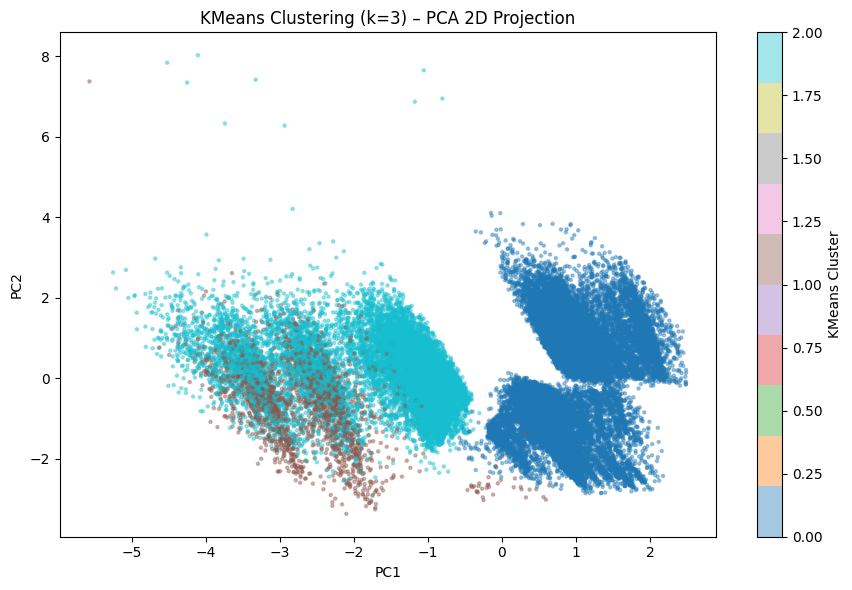

In [155]:
# Visualize KMeans clusters in PCA 2D space
palette = plt.cm.get_cmap('tab10', BEST_K)
colors_km = [palette(c) for c in kmeans_labels]

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=kmeans_labels, cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, label='KMeans Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'KMeans Clustering (k={BEST_K}) – PCA 2D Projection')
plt.tight_layout()
plt.show()

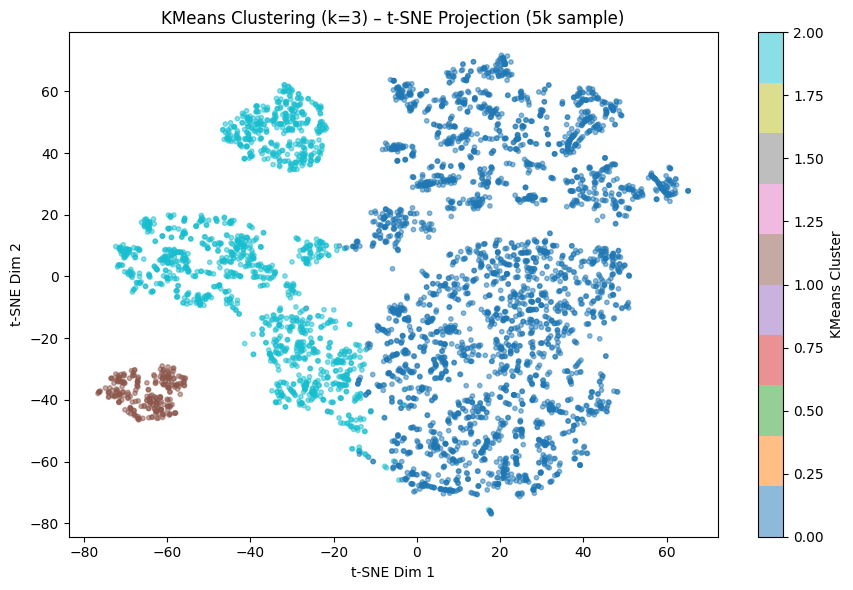

In [156]:
# Visualize KMeans clusters in t-SNE space (sample)
sample_km_labels = kmeans_labels[sample_idx]

plt.figure(figsize=(9, 6))
scatter2 = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                       c=sample_km_labels, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter2, label='KMeans Cluster')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.title(f'KMeans Clustering (k={BEST_K}) – t-SNE Projection (5k sample)')
plt.tight_layout()
plt.show()

### 3c. Agglomerative (Hierarchical) Clustering

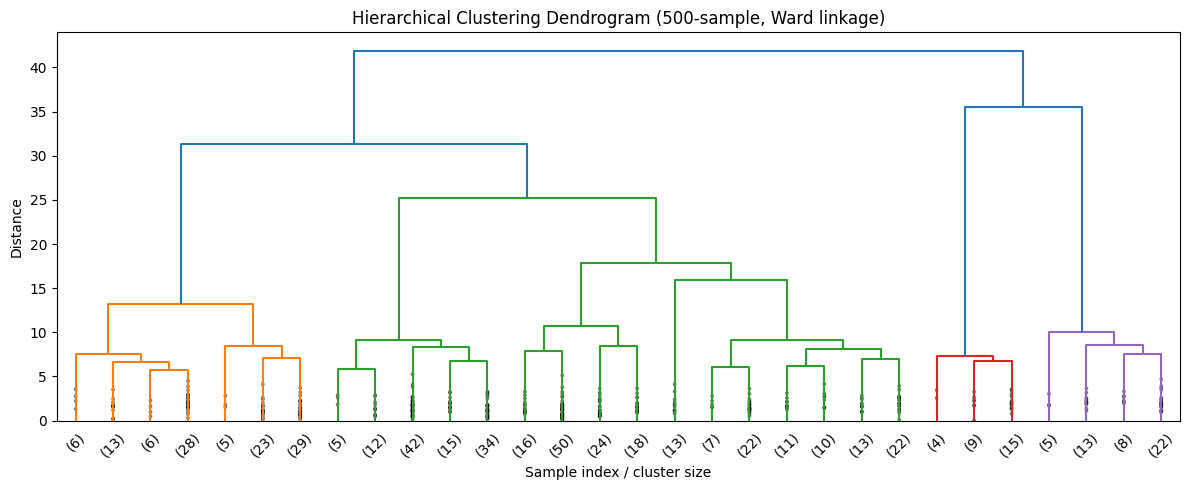

In [157]:

# Dendrogram on a small sample to visualize linkage structure
dendro_idx = np.random.choice(len(X_pca20), size=500, replace=False)
X_dendro = X_pca20[dendro_idx]

linked = linkage(X_dendro, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (500-sample, Ward linkage)')
plt.xlabel('Sample index / cluster size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:
# Fit Agglomerative Clustering with same k as KMeans for fair comparison
agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
agg_labels = agg.fit_predict(X_pca20)

adult_data_df['agg_cluster'] = agg_labels

agg_sil = silhouette_score(X_pca20, agg_labels, sample_size=5000, random_state=42)
print(f'Agglomerative Clustering – k={BEST_K}, silhouette score={agg_sil:.4f}')
print('\nCluster counts:')
print(pd.Series(agg_labels).value_counts().sort_index())

In [ ]:
# Visualize Agglomerative clusters in PCA 2D space
plt.figure(figsize=(9, 6))
scatter3 = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=agg_labels, cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter3, label='Agglomerative Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Agglomerative Clustering (k={BEST_K}) – PCA 2D Projection')
plt.tight_layout()
plt.show()

In [ ]:
# Compare silhouette scores
print('='*45)
print(f'  KMeans silhouette score       : {final_sil:.4f}')
print(f'  Agglomerative silhouette score : {agg_sil:.4f}')
print('='*45)
better = 'KMeans' if final_sil >= agg_sil else 'Agglomerative'
print(f'  => {better} produces better-separated clusters')

## 4. Interpretation & Profiling

We use **KMeans cluster labels** for profiling (choose the better-scoring model). The `income` column is used here only for post-hoc analysis, **not** as a training feature.

In [ ]:
# Rebuild a profiling dataframe with original (pre-encoding) data
# We reload the original dataset and attach cluster labels
raw_df = pd.read_csv(file_path)

# Apply the same index (no rows were dropped, only values replaced)
raw_df['kmeans_cluster'] = kmeans_labels
raw_df['agg_cluster']    = agg_labels

print('Profile dataframe shape:', raw_df.shape)
raw_df.head(3)

In [ ]:
# ── Numerical profile per KMeans cluster ──
num_profile_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
num_profile = raw_df.groupby('kmeans_cluster')[num_profile_cols].mean().round(2)
print('Mean numerical features per cluster:')
num_profile

In [ ]:
# ── Categorical mode per cluster ──
cat_profile_cols = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex']

def safe_mode(s):
    m = s.mode()
    return m.iloc[0] if len(m) else 'Unknown'

cat_profile = raw_df.groupby('kmeans_cluster')[cat_profile_cols].agg(safe_mode)
print('Most common categorical value per cluster:')
cat_profile

In [ ]:
# ── Income distribution per cluster (post-hoc, not used in training) ──
# Normalize income labels
raw_df['income_clean'] = raw_df['income'].str.strip().str.rstrip('.')

income_dist = raw_df.groupby(['kmeans_cluster', 'income_clean']).size().unstack(fill_value=0)
income_pct  = income_dist.div(income_dist.sum(axis=1), axis=0).round(3) * 100

print('Income distribution (%) per KMeans cluster:')
income_pct

In [ ]:
# ── Visualize numerical profiles ──
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_profile_cols):
    means = num_profile[col].values
    axes[i].bar(range(BEST_K), means, color=plt.cm.tab10.colors[:BEST_K])
    axes[i].set_xticks(range(BEST_K))
    axes[i].set_xticklabels([f'C{k}' for k in range(BEST_K)])
    axes[i].set_title(col)
    axes[i].set_ylabel('Mean Value')

# Income >50K % in the last subplot
if '>50K' in income_pct.columns:
    axes[5].bar(range(BEST_K), income_pct['>50K'].values,
                color=plt.cm.tab10.colors[:BEST_K])
    axes[5].set_xticks(range(BEST_K))
    axes[5].set_xticklabels([f'C{k}' for k in range(BEST_K)])
    axes[5].set_title('Income >50K (%)')
    axes[5].set_ylabel('%')

plt.suptitle('Cluster Profiles – Mean Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Heatmap of normalised cluster profiles ──
from sklearn.preprocessing import MinMaxScaler

profile_scaled = (num_profile - num_profile.min()) / (num_profile.max() - num_profile.min())

plt.figure(figsize=(10, 5))
sns.heatmap(profile_scaled.T, annot=num_profile.T, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Profile Heatmap (normalised, annotated with raw mean)')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# ── Sex & marital-status distribution per cluster ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sex
sex_dist = raw_df.groupby(['kmeans_cluster', 'sex']).size().unstack(fill_value=0)
sex_pct  = sex_dist.div(sex_dist.sum(axis=1), axis=0) * 100
sex_pct.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Sex Distribution per Cluster (%)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('%')
axes[0].legend(loc='upper right')
axes[0].tick_params(axis='x', rotation=0)

# Marital status
mar_dist = raw_df.groupby(['kmeans_cluster', 'marital-status']).size().unstack(fill_value=0)
mar_pct  = mar_dist.div(mar_dist.sum(axis=1), axis=0) * 100
mar_pct.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('Marital Status Distribution per Cluster (%)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('%')
axes[1].legend(loc='upper right', fontsize=7)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# ── Occupation distribution per cluster ──
occ_dist = raw_df.groupby(['kmeans_cluster', 'occupation']).size().unstack(fill_value=0)
occ_pct  = occ_dist.div(occ_dist.sum(axis=1), axis=0) * 100

occ_pct.plot(kind='bar', figsize=(14, 5), colormap='tab20', edgecolor='white')
plt.title('Occupation Distribution per Cluster (%)')
plt.xlabel('Cluster')
plt.ylabel('%')
plt.legend(loc='upper right', fontsize=7, ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()